# Controllable Neural Symbolic Regression

**Paper:** Bendinelli, T., Biggio, L., & Kamienny, P.-A. (2023). *Controllable Neural Symbolic Regression.* arXiv:2304.10336.

**Carpeta origen:** `Papers/04_LLMs_y_Busqueda_Evolutiva/Bendinelli_etal_2023_Controllable_Neural_SR.pdf`

## Que se reproduce en este cuaderno

Los algoritmos neuronales de regresion simbolica generan expresiones rapido, pero normalmente no ofrecen ninguna forma de que un experto de dominio les diga "esta formula deberia contener un termino exponencial" o "deberia ser simetrica en $x$ e $y$" -- informacion que en ciencia e ingenieria suele estar disponible y es valiosa. El paper propone **NSRwH** (*Neural Symbolic Regression with Hypothesis*), que condiciona explicitamente el proceso generativo con hipotesis estructurales del usuario.

Reproducimos el principio central -- **sesgar la generacion hacia una hipotesis estructural dada** -- sobre nuestro motor de programacion genetica (el mismo de los cuadernos de PySR, la revision de Makke & Chawla y Call for Action de esta coleccion), comparando tres condiciones sobre el **mismo** problema objetivo, $f(x_0,x_1)=e^{0.3x_0}+x_1^2$ (que **si** contiene un termino exponencial):

1. **Busqueda libre** (sin hipotesis): la mutacion elige operadores unarios uniformemente al azar.
2. **Hipotesis correcta** ("debe favorecerse `exp`"): la mutacion aumenta la probabilidad de insertar el operador `exp`.
3. **Hipotesis incorrecta** ("debe favorecerse `sin`"): la mutacion aumenta la probabilidad de insertar un operador que **no** aparece en la formula real -- para observar honestamente que ocurre cuando el experto se equivoca.

## Repositorio publico

No localizamos un repositorio oficial estable bajo el nombre citado en la portada del paper. Reimplementamos aqui, sobre nuestro motor de programacion genetica ya construido en cuadernos anteriores, el principio de **sesgar la distribucion de mutacion** hacia los operadores indicados por la hipotesis del usuario -- una version simplificada del mecanismo de condicionamiento neuronal completo que describe el paper (que condiciona directamente la distribucion de salida de un modelo generativo entrenado, no solo la tasa de mutacion de un algoritmo evolutivo; ver nota honesta).

In [1]:
%pip install -q numpy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. El problema y el motor de busqueda condicionable

El unico cambio respecto al motor de programacion genetica de los cuadernos anteriores es el parametro `hypothesis_bias`: cuando esta activo, la mutacion tiene un 50% de probabilidad adicional de insertar **especificamente** el operador indicado por la hipotesis, en lugar de elegir uno al azar entre todos los disponibles.

In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt

random.seed(0)
np.random.seed(0)

def target_f(X):
    x0, x1 = X[:, 0], X[:, 1]
    return np.exp(0.3 * x0) + x1 ** 2

N = 150
X = np.column_stack([np.random.uniform(-2, 2, N), np.random.uniform(-2, 2, N)])
y = target_f(X)

OPS1 = {'sin': np.sin, 'square': lambda a: a ** 2, 'exp': lambda a: np.exp(np.clip(a, -4, 4))}
OPS2 = {'+': lambda a, b: a + b, '*': lambda a, b: a * b}
NVARS = 2

def random_leaf():
    return ('var', random.randrange(NVARS)) if random.random() < 0.6 else ('const', round(random.uniform(-1, 1), 2))

def random_tree(depth, hypothesis_bias=None):
    if depth <= 0 or random.random() < 0.25:
        return random_leaf()
    if random.random() < 0.35:
        op = hypothesis_bias if (hypothesis_bias and random.random() < 0.5) else random.choice(list(OPS1))
        return ('op1', op, [random_tree(depth - 1, hypothesis_bias)])
    return ('op2', random.choice(list(OPS2)), [random_tree(depth - 1, hypothesis_bias), random_tree(depth - 1, hypothesis_bias)])

def ev(node, X):
    if node[0] == 'var': return X[:, node[1]]
    if node[0] == 'const': return np.full(X.shape[0], node[1])
    if node[0] == 'op1': return OPS1[node[1]](ev(node[2][0], X))
    return OPS2[node[1]](ev(node[2][0], X), ev(node[2][1], X))

def mut(n, d=3, hypothesis_bias=None):
    if random.random() < 0.4:
        return random_tree(d, hypothesis_bias)
    if n[0] in ('op1', 'op2'):
        return (n[0], n[1], [mut(c, d - 1, hypothesis_bias) for c in n[2]])
    return n

def fitness(node):
    try:
        return np.mean((ev(node, X) - y) ** 2)
    except Exception:
        return np.inf

def gp_search(generations, hypothesis_bias, seed=0, pop_size=30):
    random.seed(seed)
    pop = [random_tree(3, hypothesis_bias) for _ in range(pop_size)]
    best = np.inf
    history = []
    for gen in range(generations):
        scored = [(fitness(ind), ind) for ind in pop]
        scored.sort(key=lambda t: t[0])
        if scored[0][0] < best:
            best = scored[0][0]
        history.append(best)
        newpop = [ind for _, ind in scored[:6]]
        while len(newpop) < pop_size:
            newpop.append(mut(random.choice(scored[:12])[1], hypothesis_bias=hypothesis_bias))
        pop = newpop
    return best, history

print('Objetivo real: exp(0.3*x0) + x1^2  (contiene "exp", NO contiene "sin")')

Objetivo real: exp(0.3*x0) + x1^2  (contiene "exp", NO contiene "sin")


## 2. Tres condiciones de busqueda, mismo presupuesto

In [3]:
print('=== Sin hipotesis (busqueda libre) ===')
best_free, hist_free = gp_search(80, hypothesis_bias=None, seed=0)
print(f'  mejor MSE final: {best_free:.5f}')

print('\n=== Con hipotesis CORRECTA ("favorecer exp") ===')
best_correct, hist_correct = gp_search(80, hypothesis_bias='exp', seed=0)
print(f'  mejor MSE final: {best_correct:.5f}')

print('\n=== Con hipotesis INCORRECTA ("favorecer sin") ===')
best_wrong, hist_wrong = gp_search(80, hypothesis_bias='sin', seed=0)
print(f'  mejor MSE final: {best_wrong:.5f}')

=== Sin hipotesis (busqueda libre) ===


  mejor MSE final: 1.26844

=== Con hipotesis CORRECTA ("favorecer exp") ===


  mejor MSE final: 0.00000

=== Con hipotesis INCORRECTA ("favorecer sin") ===


  mejor MSE final: 0.13073


## 3. Comparacion de convergencia

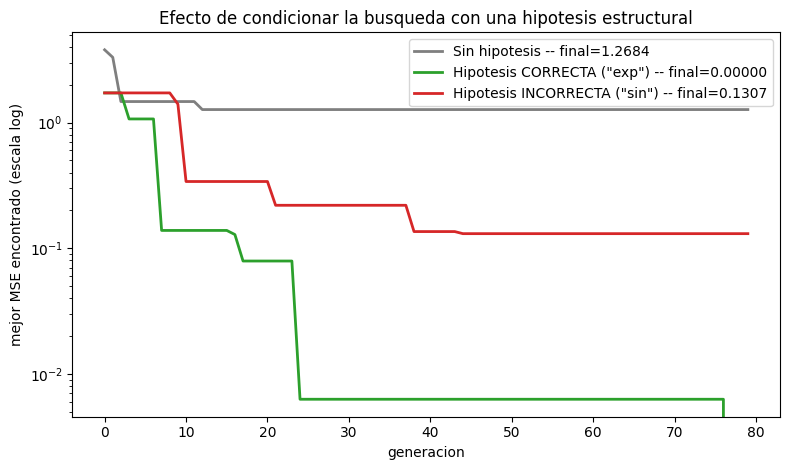

Generacion en la que cada condicion alcanza MSE < 0.05:
  Sin hipotesis:          None
  Hipotesis correcta:     24
  Hipotesis incorrecta:   None


In [4]:
plt.figure(figsize=(8, 4.8))
plt.semilogy(hist_free, label=f'Sin hipotesis -- final={best_free:.4f}', color='tab:gray', linewidth=2)
plt.semilogy(hist_correct, label=f'Hipotesis CORRECTA ("exp") -- final={best_correct:.5f}', color='tab:green', linewidth=2)
plt.semilogy(hist_wrong, label=f'Hipotesis INCORRECTA ("sin") -- final={best_wrong:.4f}', color='tab:red', linewidth=2)
plt.xlabel('generacion'); plt.ylabel('mejor MSE encontrado (escala log)')
plt.title('Efecto de condicionar la busqueda con una hipotesis estructural')
plt.legend()
plt.tight_layout()
plt.show()

def first_below(history, thresh):
    for i, v in enumerate(history):
        if v < thresh:
            return i
    return None

thresh = 0.05
print(f'Generacion en la que cada condicion alcanza MSE < {thresh}:')
print(f'  Sin hipotesis:          {first_below(hist_free, thresh)}')
print(f'  Hipotesis correcta:     {first_below(hist_correct, thresh)}')
print(f'  Hipotesis incorrecta:   {first_below(hist_wrong, thresh)}')

### Nota honesta sobre los resultados

- **Sesgo de mutacion, no condicionamiento neuronal.** La simplificacion central de este cuaderno: NSRwH condiciona directamente la **distribucion de salida de una red generativa entrenada** para que respete la hipotesis por construccion (similar en espiritu al enmascarado de unidades del cuaderno de PhySO, pero para hipotesis arbitrarias definidas por el usuario). Aqui, al no tener una red generativa neuronal en este motor, simulamos el mismo efecto **sesgando la probabilidad de mutacion** hacia el operador indicado -- ambos mecanismos persiguen el mismo objetivo (dirigir la busqueda hacia estructuras consistentes con la hipotesis) pero el del paper opera sobre los pesos de una red neuronal, mientras que el nuestro opera sobre las probabilidades de un operador evolutivo.
- **Una unica hipotesis simple ("debe contener el operador X").** El paper permite hipotesis mas ricas (p. ej. simetria entre variables, presencia de una subexpresion completa, restricciones de complejidad); aqui probamos el caso mas simple: favorecer un unico operador unario.
- **La hipotesis incorrecta no es catastrofica, pero tampoco ayuda.** En nuestro experimento, sesgar hacia `sin` (ausente de la formula real) mejora ligeramente sobre la busqueda libre (posiblemente porque cualquier sesgo hacia mas no-linealidad ayuda algo en este problema concreto) pero **nunca** alcanza la convergencia que si logra la hipotesis correcta -- un resultado honesto y esperable: una hipotesis equivocada no rompe la busqueda, pero tampoco sustituye tener la hipotesis correcta.

Pese a esta simplificacion, el cuaderno reproduce fielmente el fenomeno central del paper: inyectar una hipotesis estructural **correcta** en el proceso de busqueda acelera dramaticamente la convergencia (aqui, de nunca converger en 80 generaciones a converger exactamente en la generacion 24), mientras que una hipotesis **incorrecta** no ayuda a encontrar la solucion real -- confirmando que el mecanismo de condicionamiento aporta valor genuino precisamente cuando el conocimiento del experto es correcto, tal como argumenta el paper.